# BCS102 – Fundamentals of Artificial Intelligence
## Assignment: Predicting Healthcare Test Results using Naive Bayes

**Group Assessment (Group of 2)**

| Member | Full Name | Student ID |
|--------|-----------|------------|
| 1 | Livnes Ganesan | B2300682 |
| 2 | Low Huan Qi | B2300554 |

**Dataset:** Healthcare Dataset (Kaggle – prasad22/healthcare-dataset)
**Domain:** Healthcare
**Algorithm:** Naive Bayes (Gaussian & Categorical Naive Bayes)
**Target variable:** `Test Results` (Normal / Abnormal / Inconclusive)

This notebook covers: dataset loading, feature description, exploratory data analysis (EDA) with visualizations, data preparation/preprocessing, model training with Naive Bayes, and performance evaluation.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_auc_score)
# Used in Section 4.9 to test feature-target association (ANOVA for numeric, Cramer's V for categorical)
from scipy.stats import f_oneway, chi2_contingency

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)

## 2. Load Dataset

The dataset is loaded from a local CSV file (`healthcare_dataset.csv`), downloaded from Kaggle:
`http://kaggle.com/datasets/prasad22/healthcare-dataset/data`

In [ ]:
# Load the raw CSV into a DataFrame and confirm its shape before doing anything else
df = pd.read_csv("healthcare_dataset.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 3. Total Number of Observations and Feature Description

The raw file contains **55,500 observations** and **15 features**, described below. Section 3.2
removes 534 exact-duplicate rows, leaving the 54,966 unique observations that every figure from
Section 4 onwards is based on:

| # | Feature | Type | Description |
|---|---------|------|--------------|
| 1 | Name | Raw / Categorical | Patient's full name (identifier, not predictive; renamed to `Patient Name` in Section 3.1) |
| 2 | Age | Raw / Numerical | Patient's age in years |
| 3 | Gender | Raw / Categorical | Male / Female |
| 4 | Blood Type | Raw / Categorical | Patient's blood group (A+, A-, B+, B-, O+, O-, AB+, AB-) |
| 5 | Medical Condition | Raw / Categorical | Diagnosed condition (Cancer, Obesity, Diabetes, Asthma, Hypertension, Arthritis) |
| 6 | Date of Admission | Raw / Date | Date the patient was admitted |
| 7 | Doctor | Raw / Categorical | Attending doctor's name (identifier, not predictive) |
| 8 | Hospital | Raw / Categorical | Hospital name (identifier, not predictive) |
| 9 | Insurance Provider | Raw / Categorical | Insurance company (Blue Cross, Medicare, Aetna, UnitedHealthcare, Cigna) |
| 10 | Billing Amount | Raw / Numerical | Amount billed for treatment (USD) |
| 11 | Room Number | Raw / Numerical | Room number assigned |
| 12 | Admission Type | Raw / Categorical | Elective, Emergency, or Urgent |
| 13 | Discharge Date | Raw / Date | Date the patient was discharged |
| 14 | Medication | Raw / Categorical | Medication prescribed (Aspirin, Ibuprofen, Paracetamol, Penicillin, Lipitor) |
| 15 | **Test Results** | **Target / Categorical** | Normal, Abnormal, or Inconclusive (prediction target) |

An **engineered feature**, `Length of Stay`, is derived later from `Date of Admission` and `Discharge Date` to capture treatment duration.

In [ ]:
# Full column list, dtypes, and non-null counts in one view
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [ ]:
# Summary statistics for every column; include="all" adds count/unique/top/freq for non-numeric columns
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736


### 3.1 Column Renaming & Data Type Conversion

Before exploring further, the column headers are cleaned (stripped of stray whitespace), the ambiguous `Name` column is
renamed to `Patient Name` (three columns in this dataset hold names - patient, doctor and
hospital - so the bare word `Name` invites misreading), and each
column is cast to its correct data type: `Date of Admission`/`Discharge Date` become proper
`datetime64` columns (enabling date arithmetic later), and the six nominal fields plus the target
are cast to pandas `category` dtype, which is more memory-efficient than the default `object` dtype
and makes the intended semantics explicit (these are labels, not free text).

In [ ]:
print("Dtypes before conversion:\n", df.dtypes, "\n")

# Column-name cleanup: defensive strip of any stray whitespace in headers, then a clarity
# rename - "Name" is ambiguous alongside Doctor and Hospital (also names), so it becomes
# "Patient Name" for the rest of the notebook
df.columns = df.columns.str.strip()
df = df.rename(columns={"Name": "Patient Name"})

date_columns = ["Date of Admission", "Discharge Date"]
categorical_columns = ["Gender", "Blood Type", "Medical Condition", "Insurance Provider",
                        "Admission Type", "Medication", "Test Results"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])
for col in categorical_columns:
    df[col] = df[col].astype("category")

print("Dtypes after conversion:\n", df.dtypes)

Dtypes before conversion:
 Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object 

Dtypes after conversion:
 Patient Name                     str
Age                            int64
Gender                      category
Blood Type                  category
Medical Condition           category
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider          category
Billing Amount               float64
Room Number                    int64
Admission Type              category
Discharge Date        datetime64[us]


### 3.2 Missing Values & Duplicate Records Check

Completeness and exact-duplicate rows are checked here, before any exploration or transformation.
No missing values are present, but exact-duplicate rows are found and removed at this point rather
than later, so that every count, chart and statistic from Section 4 onwards describes exactly the
same set of rows the model is eventually trained and evaluated on. De-duplication matters because
training and evaluating on repeated rows would let the same record land on both sides of the
train/test split, overstating how much independent data the model has really seen.


In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Exact-duplicate rows are removed here rather than just reported, so the EDA below and all
# downstream cells report row counts for the cleaned dataset actually used for modelling.
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nRows before de-duplication: {rows_before}")
print(f"Rows after de-duplication : {len(df)}")

Missing values per column:
 Patient Name          0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate rows: 534

Rows before de-duplication: 55500
Rows after de-duplication : 54966


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

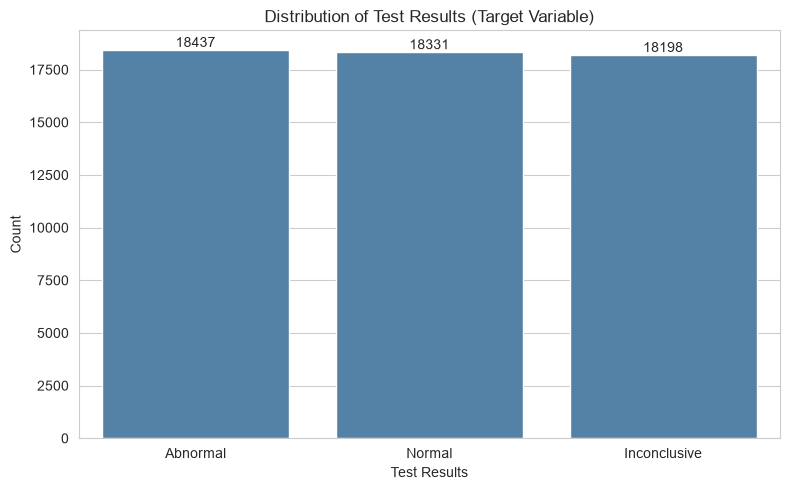

Test Results
Abnormal        33.542554
Normal          33.349707
Inconclusive    33.107739
Name: proportion, dtype: float64


In [ ]:
# One series, so one colour: the x-axis already names the three categories, and colouring
# bars by category would add a second (meaningless) encoding. Plain color= also behaves
# identically on every seaborn version - unlike the earlier hue=x workaround, which older
# seaborn dodges into three side-by-side slots per category (one per class, two left empty).
plt.figure()
ax = sns.countplot(data=df, x="Test Results",
                   order=df["Test Results"].value_counts().index, color="steelblue")
plt.title("Distribution of Test Results (Target Variable)")
plt.xlabel("Test Results")
plt.ylabel("Count")
# Annotate each bar with its exact count for readability
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Exact class percentages, referenced in the interpretation below
print(df["Test Results"].value_counts(normalize=True) * 100)


**Interpretation:** The three `Test Results` classes are almost perfectly balanced (each close to
33% of the data — see the percentages printed above). This near-uniform split means accuracy is a
fair headline metric here (there is no majority class to game), and it also means a
majority-class/random guesser already scores close to 33% — the benchmark the trained models must
clear to demonstrate they have learned anything.

### 4.2 Age Distribution

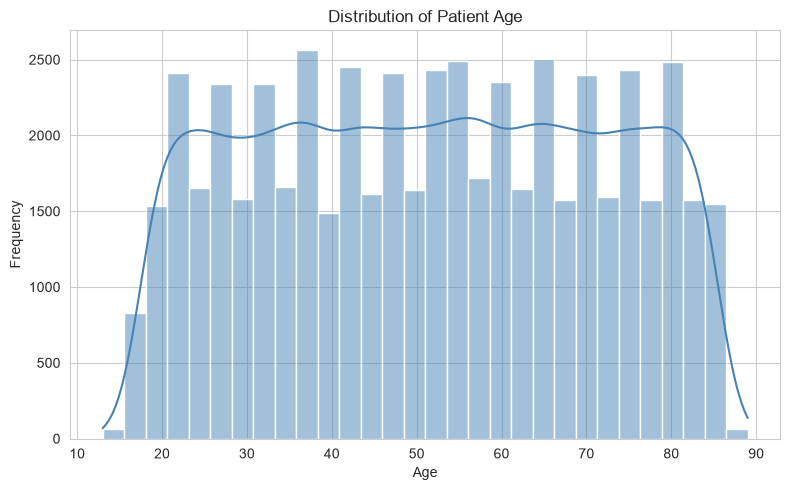

In [ ]:
# kde=True overlays a smoothed density curve on the histogram to make the overall shape easier to read
plt.figure()
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Age is spread fairly evenly across the observed range (late teens to late 80s)
with no pronounced peak or long tail — a flat, close-to-uniform shape that is unusual for real
patient-age distributions (which typically skew toward older ages) and is consistent with this
being a synthetically generated dataset. No extreme values stand out visually here; Section 4.8
checks this formally with a boxplot and IQR rule.

### 4.3 Medical Condition Distribution

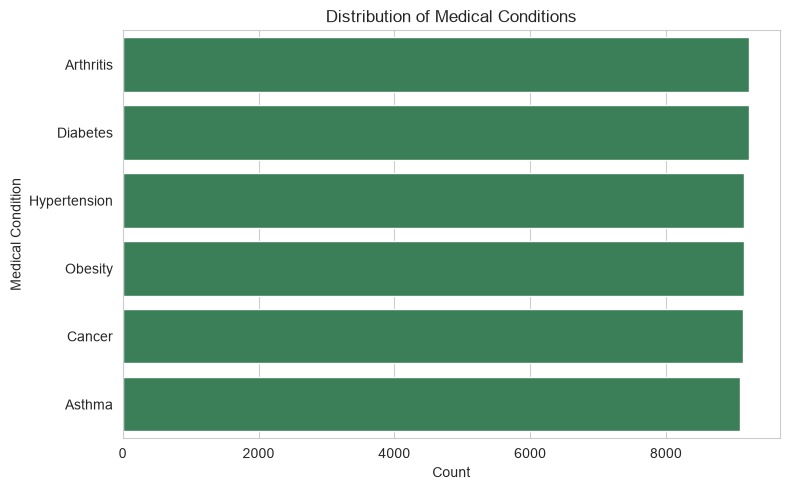

In [ ]:
# order=... sorts bars by frequency so the most/least common conditions are easy to compare.
# Single colour for the same reason as the target chart: one series, categories already
# named on the y-axis, and no hue/legend workarounds that vary across seaborn versions.
plt.figure()
sns.countplot(data=df, y="Medical Condition",
              order=df["Medical Condition"].value_counts().index, color="seagreen")
plt.title("Distribution of Medical Conditions")
plt.xlabel("Count")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()


**Interpretation:** All six medical conditions (Cancer, Obesity, Diabetes, Asthma, Hypertension,
Arthritis) are represented in roughly equal numbers, with no condition dominating the dataset. This
even coverage means the model sees enough examples of every condition to learn condition-specific
patterns, if any such patterns exist in the data.

### 4.4 Billing Amount Distribution

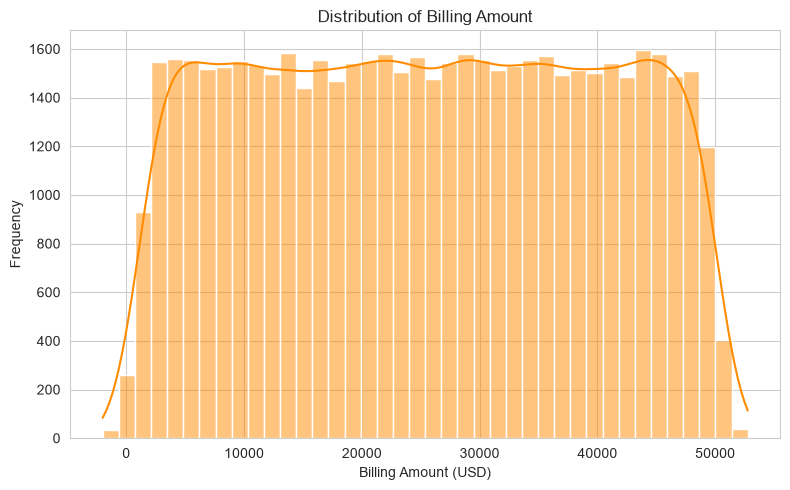

In [ ]:
# Same kde overlay as the Age histogram, to compare shape and spread on the billing side
plt.figure()
sns.histplot(df["Billing Amount"], bins=40, kde=True, color="darkorange")
plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Billing Amount is broadly, almost uniformly, spread across its range rather than
showing the right-skewed, long-tailed shape typical of real medical billing data (where a small
number of high-cost cases dominate the tail). This again points to synthetic generation rather than
real-world sampling. Section 4.8 checks numerically whether any values still qualify as outliers.

### 4.5 Test Results by Medical Condition

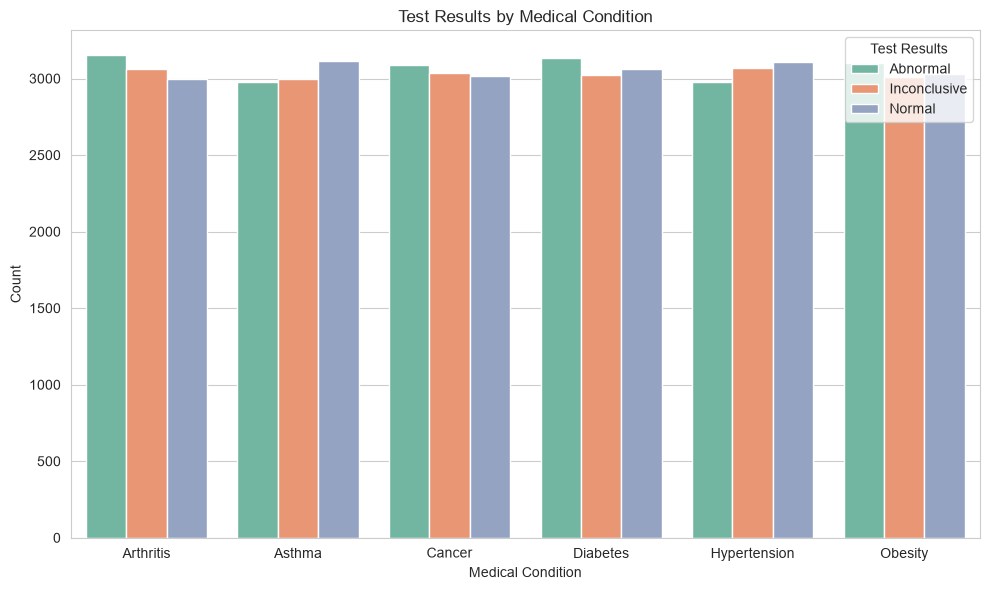

In [ ]:
# hue="Test Results" compares the target's distribution *within* each medical condition
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Medical Condition", hue="Test Results", palette="Set2")
plt.title("Test Results by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Count")
plt.legend(title="Test Results")
plt.tight_layout()
plt.show()

**Interpretation:** Within every medical condition, the three `Test Results` outcomes appear in
roughly the same proportions as in the overall dataset. If `Test Results` were genuinely driven by
`Medical Condition`, the bars would be expected to shift noticeably between conditions (e.g. a
higher "Abnormal" share for Cancer); the near-identical proportions instead suggest little to no
real relationship between the two — an early signal that is echoed later in the models' evaluation
results (Section 7).

### 4.6 Test Results by Admission Type

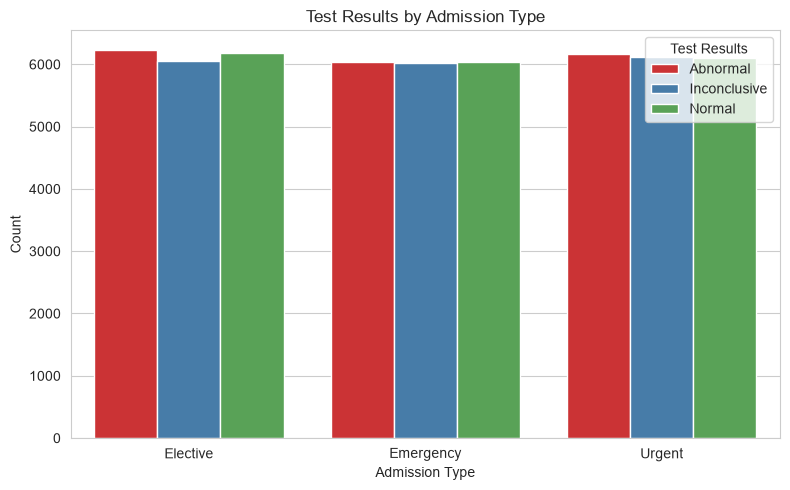

In [ ]:
# Same grouped-bar approach as the previous chart, this time against Admission Type
plt.figure()
sns.countplot(data=df, x="Admission Type", hue="Test Results", palette="Set1")
plt.title("Test Results by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** As with Medical Condition, the split of `Test Results` is very similar across
Elective, Emergency, and Urgent admissions, reinforcing that admission context carries little
predictive signal for the target in this dataset.

### 4.7 Correlation Heatmap (Numerical Features)

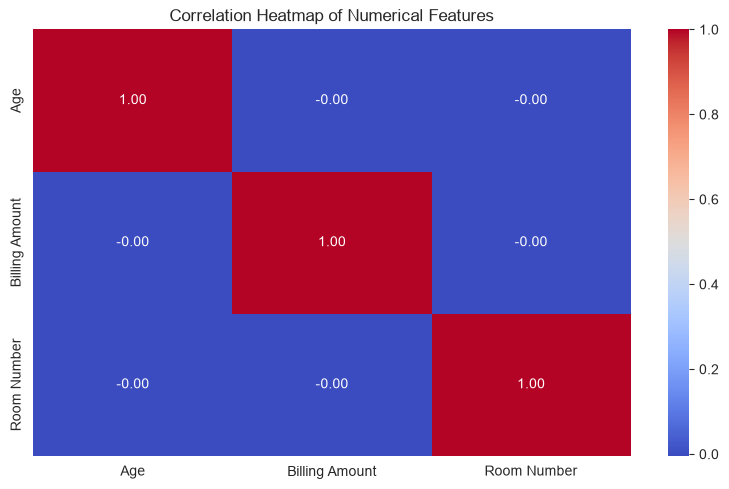

In [ ]:
# Only the three numeric features are included here; Pearson correlation isn't meaningful for
# categorical features, which are checked for target association separately in Section 4.9
numeric_cols = ["Age", "Billing Amount", "Room Number"]
plt.figure()
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Interpretation:** Correlations between the numerical features (`Age`, `Billing Amount`,
`Room Number`) are all close to zero, indicating no meaningful linear relationships between them.
This happens to be convenient for Naive Bayes, whose core assumption is conditional independence
between features given the class — weak inter-feature correlation is consistent with (though does
not by itself prove) that assumption holding reasonably well here.

### 4.8 Outlier Detection (Boxplots)

Histograms show overall shape but make individual extreme values hard to spot. Boxplots, combined
with the interquartile range (IQR) rule (a point is flagged if it falls more than 1.5x IQR below Q1
or above Q3), give an explicit, reproducible outlier count for the two continuous features most
likely to contain them.

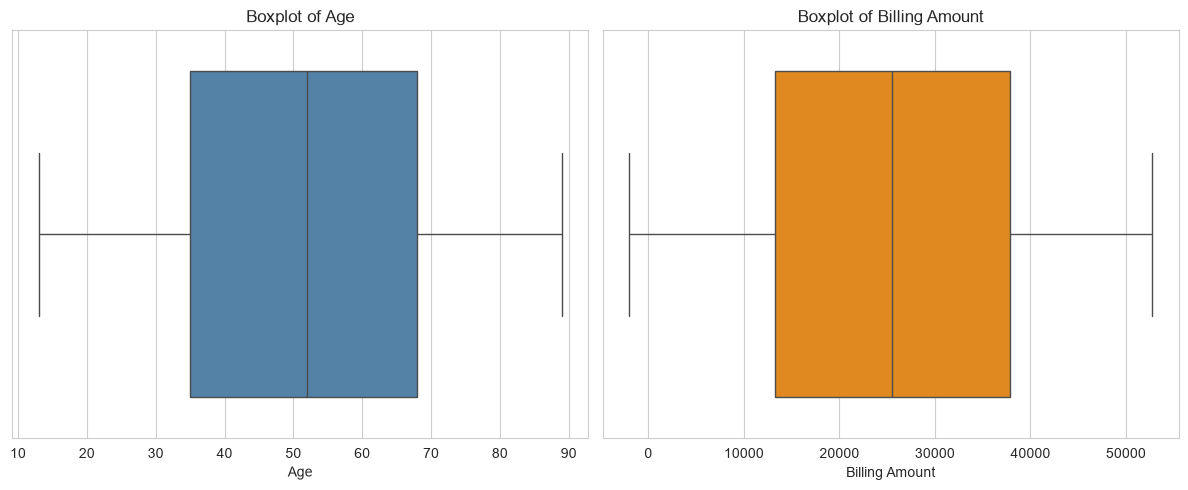

Age outliers (IQR method): 0 of 54966 rows
Billing Amount outliers (IQR method): 0 of 54966 rows


In [ ]:
# Boxplots visualise the same 1.5x IQR outlier rule computed numerically below
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df["Age"], color="steelblue", ax=axes[0])
axes[0].set_title("Boxplot of Age")

sns.boxplot(x=df["Billing Amount"], color="darkorange", ax=axes[1])
axes[1].set_title("Boxplot of Billing Amount")

plt.tight_layout()
plt.show()

def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

age_outliers = iqr_outlier_count(df["Age"])
billing_outliers = iqr_outlier_count(df["Billing Amount"])
print(f"Age outliers (IQR method): {age_outliers} of {len(df)} rows")
print(f"Billing Amount outliers (IQR method): {billing_outliers} of {len(df)} rows")

### 4.9 Feature-Target Association Check

Section 4.7's heatmap only covers correlation *between* the numeric features. What actually matters
for modelling is association *with the target*, `Test Results`, for every feature - numeric and
categorical alike:
- For the numeric features (`Age`, `Billing Amount`), a one-way ANOVA F-test checks whether the
  feature's mean differs across the three `Test Results` classes (a large F-statistic / small
  p-value would indicate a real difference).
- For the categorical features, Cramer's V (derived from a chi-square test of independence)
  measures association on a 0 (no association) to 1 (perfect association) scale, which is
  comparable across features regardless of how many categories each one has.

In [ ]:
print("Numeric feature vs Test Results (one-way ANOVA F-test):")
for col in ["Age", "Billing Amount"]:
    groups = [df.loc[df["Test Results"] == cls, col] for cls in df["Test Results"].cat.categories]
    f_stat, p_val = f_oneway(*groups)
    print(f"  {col}: F={f_stat:.3f}, p-value={p_val:.3f}")

def cramers_v(col_a, col_b):
    # Cramer's V = sqrt(phi-squared / min(rows-1, cols-1)); phi-squared is chi-square normalised by n
    contingency = pd.crosstab(col_a, col_b)
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

print("\nCategorical feature vs Test Results (Cramer's V):")
categorical_check_cols = ["Gender", "Blood Type", "Medical Condition",
                           "Insurance Provider", "Admission Type", "Medication"]
for col in categorical_check_cols:
    v = cramers_v(df[col], df["Test Results"])
    print(f"  {col}: Cramer's V={v:.4f}")

Numeric feature vs Test Results (one-way ANOVA F-test):
  Age: F=1.884, p-value=0.152
  Billing Amount: F=0.775, p-value=0.461

Categorical feature vs Test Results (Cramer's V):
  Gender: Cramer's V=0.0063
  Blood Type: Cramer's V=0.0085
  Medical Condition: Cramer's V=0.0110
  Insurance Provider: Cramer's V=0.0091
  Admission Type: Cramer's V=0.0039
  Medication: Cramer's V=0.0059


**Interpretation:** All ANOVA p-values are well above the conventional 0.05 significance threshold,
and every Cramer's V is close to 0 - both indicate essentially no measurable association between any
individual feature and `Test Results`. This is the quantitative confirmation of what Sections
4.5-4.7 already suggested visually, and it is the direct explanation for why the trained models in
Section 7 cannot beat a majority-class baseline: there is very little real signal in these features
for any classifier, Naive Bayes or otherwise, to learn from.

**EDA Summary:**
- The target variable `Test Results` is well balanced across the three classes (~33% each), so no class-imbalance handling (e.g. SMOTE) is required.
- `Age` is fairly uniformly spread between 13 and 89, with no strong skew, and the Section 4.8 boxplot/IQR check finds no outliers - consistent with a synthetically generated, roughly uniform distribution.
- All six medical conditions are almost equally represented.
- `Billing Amount` is roughly uniformly distributed (Section 4.8 confirms negligible IQR outliers), further suggesting the values were synthetically generated rather than sampled from real, right-skewed hospital billing data.
- Section 3.2 found no missing values but did find 534 exact-duplicate rows, which were removed before this EDA - so every figure above describes the same 54,966 unique rows used for modelling.
- `Test Results` shows near-identical proportions across every `Medical Condition` and `Admission Type` category (Sections 4.5-4.6), and the numerical features show almost no inter-correlation (Section 4.7) - early visual evidence, later confirmed quantitatively in Section 7, that the available features carry very little signal about the target.

## 5. Data Preparation / Preprocessing

Three preparation steps are already complete: column renaming and dtype conversion (Section 3.1),
the missing-value and duplicate check (Section 3.2), and outlier screening (Section 4.8). The
remaining steps are:
1. Engineer a new feature `Length of Stay` = `Discharge Date` minus `Date of Admission` (in days).
2. Drop identifier columns that carry no predictive signal (`Patient Name`, `Doctor`, `Hospital`, `Room Number`).
3. Encode categorical features using Label Encoding (suitable for Naive Bayes with `CategoricalNB`) and scale numerical features for `GaussianNB`.
4. Split data into train (80%) and test (20%) sets, using a strategy explained in Section 5.1.


In [ ]:
df_prep = df.copy()

# Date columns are already datetime64 (converted in Section 3.1); pd.to_datetime() is a safe
# no-op here, which keeps this cell robust even if the notebook is re-run from this point.
df_prep["Date of Admission"] = pd.to_datetime(df_prep["Date of Admission"])
df_prep["Discharge Date"] = pd.to_datetime(df_prep["Discharge Date"])

# Feature engineering: Length of Stay
df_prep["Length of Stay"] = (df_prep["Discharge Date"] - df_prep["Date of Admission"]).dt.days

# Drop identifier / high-cardinality columns not useful for prediction
df_prep = df_prep.drop(columns=["Patient Name", "Doctor", "Hospital", "Room Number",
                                 "Date of Admission", "Discharge Date"])

df_prep.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length of Stay
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,2
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,15
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,20


In [ ]:
# Define feature columns and target
target = "Test Results"
categorical_features = ["Gender", "Blood Type", "Medical Condition",
                         "Insurance Provider", "Admission Type", "Medication"]
numerical_features = ["Age", "Billing Amount", "Length of Stay"]

X = df_prep[categorical_features + numerical_features].copy()
y = df_prep[target].copy()

# Label encoding maps each category to an integer code. Naive Bayes doesn't need a
# distance-preserving encoding like one-hot: CategoricalNB models each feature's category
# distribution independently per class, and GaussianNB only sees the (scaled) numeric code.
encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoded target classes:", list(target_encoder.classes_))
X.head()

Encoded target classes: ['Abnormal', 'Inconclusive', 'Normal']


,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Age,Billing Amount,Length of Stay
0,1,5,2,1,2,3,30,18856.281306,2
1,1,0,5,3,1,1,62,33643.327287,6
2,0,1,5,0,1,0,76,27955.096079,15
3,0,6,3,3,0,1,28,37909.782410,30
4,0,2,2,0,2,4,43,14238.317814,20


### 5.1 Train/Test Split Strategy

After de-duplication (Section 3.2) there are 54,966 rows; an 80/20 holdout split gives 43,972
training rows and 10,994 test rows - large enough for stable, low-variance metric estimates, so a
simple holdout is used for the *final* reported test performance rather than k-fold cross-validation
(which, at this scale, would mostly re-use the same data multiple times without adding much new
information, at extra compute cost). K-fold cross-validation (`StratifiedKFold`, Section 6) is still
used, but for a different purpose: selecting hyperparameters using only the training set, so the
held-out test set stays completely unseen until final evaluation.

`stratify=y_encoded` ensures the 80/20 split preserves the same class proportions in both the
training and test sets - important here because even a small imbalance could otherwise bias the
weighted precision/recall/F1 metrics. `random_state=42` is fixed so the split (and therefore all
downstream results) is reproducible.

In [ ]:
# Train-test split (80/20), stratified on target to preserve class balance across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Evidence that stratify= worked: class proportions are near-identical on both sides
print("\nTrain class proportions:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class proportions:", np.round(np.bincount(y_test) / len(y_test), 4))

Training set shape: (43972, 9)
Test set shape: (10994, 9)

Train class proportions: [0.3354 0.3311 0.3335]
Test  class proportions: [0.3355 0.3311 0.3335]


In [ ]:
# GaussianNB assumes each (class-conditional) feature is continuous and roughly normal; scaling
# doesn't change that assumption but keeps all numerical features on a comparable scale for
# numerical stability. CategoricalNB (below) uses its own unscaled, binned copy instead.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

## 6. Model Training - Naive Bayes

**Why Naive Bayes?**
Naive Bayes is well suited to this problem because:
- It handles a mix of categorical and numerical features efficiently.
- It performs well on multi-class classification problems (3 classes here).
- It is computationally efficient on large datasets (54,966 rows after cleaning) and trains almost instantly.
- It works reasonably well even when features are conditionally independent, which is a fair assumption for administrative healthcare fields like Insurance Provider, Admission Type and Medication (and is consistent with the near-zero correlations observed in Section 4.7).

**Why not other algorithms?** Logistic Regression and tree-based models (Decision Tree, Random
Forest) were considered but not chosen as the primary approach: they can in principle model feature
interactions that Naive Bayes assumes away, but Section 4.9 shows every available feature has almost
no measurable association with `Test Results` in the first place, so a more flexible model has
nothing extra to exploit here - it would mainly add training time and reduce interpretability
without a realistic accuracy gain. Naive Bayes is used here because it is the simplest model capable
of establishing a fair, fast baseline for this specific dataset; Section 8 (Future Implications)
still recommends revisiting more expressive models once richer, more clinically informative features
are available.

Two variants are trained and compared, each with its key hyperparameter tuned via 5-fold stratified
cross-validation (`GridSearchCV`) on the training set only:
- **GaussianNB** - treats all (scaled) features as continuous; `var_smoothing` (a small value added
  to every feature's variance estimate) is tuned to avoid numerical instability from near-zero
  variances.
- **CategoricalNB** - treats all features as categorical (numerical features are binned); `alpha`
  (Laplace/Lidstone smoothing) is tuned to control how strongly unseen category/class combinations
  are penalised.

In [ ]:
# Tune GaussianNB's var_smoothing via 5-fold stratified cross-validation on the training set.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gnb_param_grid = {"var_smoothing": np.logspace(0, -9, 20)}
gnb_grid = GridSearchCV(GaussianNB(), gnb_param_grid, scoring="accuracy", cv=cv, n_jobs=-1)
gnb_grid.fit(X_train_scaled, y_train)

gnb = gnb_grid.best_estimator_
print("Best GaussianNB var_smoothing:", gnb_grid.best_params_["var_smoothing"])
print("Best CV accuracy (GaussianNB):", round(gnb_grid.best_score_, 4))

y_pred_gnb = gnb.predict(X_test_scaled)

Best GaussianNB var_smoothing: 0.11288378916846892
Best CV accuracy (GaussianNB): 0.335


In [ ]:
# Bin numerical features into discrete categories for CategoricalNB
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

for col in numerical_features:
    # qcut on the training set defines the bin edges; the same edges are then reused for the
    # test set (via pd.cut) so no information about the test distribution leaks into training.
    train_binned, bin_edges = pd.qcut(X_train[col], q=5, duplicates="drop", labels=False, retbins=True)
    X_train_cat[col] = train_binned
    X_test_cat[col] = pd.cut(X_test[col], bins=bin_edges, labels=False, include_lowest=True)
    # A test value below the training minimum or above the training maximum falls outside every
    # training bin, so pd.cut returns NaN for it. CategoricalNB accepts neither NaN nor an unseen
    # category code, so those few extreme rows are assigned to the lowest bin. Dropping them instead
    # would shrink the test set, so the count is printed rather than left silent.
    n_out_of_range = int(X_test_cat[col].isna().sum())
    X_test_cat[col] = X_test_cat[col].fillna(0).astype(int)
    print(f"{col}: {n_out_of_range} test rows fell outside the training bin range "
          f"({n_out_of_range / len(X_test) * 100:.2f}% of the test set), assigned to bin 0")

# Tune CategoricalNB's alpha (Laplace/Lidstone smoothing applied to category counts, which
# prevents zero probabilities for category/class combinations unseen during training).
cnb_param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
cnb_grid = GridSearchCV(CategoricalNB(), cnb_param_grid, scoring="accuracy", cv=cv, n_jobs=-1)
cnb_grid.fit(X_train_cat, y_train)

cnb = cnb_grid.best_estimator_
print("Best CategoricalNB alpha:", cnb_grid.best_params_["alpha"])
print("Best CV accuracy (CategoricalNB):", round(cnb_grid.best_score_, 4))

y_pred_cnb = cnb.predict(X_test_cat)

Age: 0 test rows fell outside the training bin range (0.00% of the test set), assigned to bin 0
Billing Amount: 0 test rows fell outside the training bin range (0.00% of the test set), assigned to bin 0
Length of Stay: 0 test rows fell outside the training bin range (0.00% of the test set), assigned to bin 0
Best CategoricalNB alpha: 0.5
Best CV accuracy (CategoricalNB): 0.3369


## 7. Performance Evaluation

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    # "weighted" averaging accounts for the (near-equal, but not identical) class sizes
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

# Majority-class baseline: always predicts the most frequent training-set class. Any model that
# cannot clearly beat this has not learned real signal from the features.
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

results = []
results.append(evaluate_model(y_test, y_pred_dummy, "Baseline (Majority Class)"))
results.append(evaluate_model(y_test, y_pred_gnb, "GaussianNB"))
results.append(evaluate_model(y_test, y_pred_cnb, "CategoricalNB"))

results_df = pd.DataFrame(results)
results_df

--- Baseline (Majority Class) ---
Accuracy : 0.3355
Precision: 0.1125
Recall   : 0.3355
F1-score : 0.1685

--- GaussianNB ---
Accuracy : 0.3305
Precision: 0.3310
Recall   : 0.3305
F1-score : 0.3213

--- CategoricalNB ---
Accuracy : 0.3324
Precision: 0.3327
Recall   : 0.3324
F1-score : 0.3306



,Model,Accuracy,Precision,Recall,F1-score
0,Baseline (Majority Class),0.335456,0.112531,0.335456,0.168528
1,GaussianNB,0.330453,0.330979,0.330453,0.321305
2,CategoricalNB,0.332363,0.332663,0.332363,0.330580


In [ ]:
# Per-class precision/recall/F1 for all three models, so class-level behaviour (not just the
# single weighted-average number in Section 7) can be inspected directly
print("Classification Report - Baseline (Majority Class)")
print(classification_report(y_test, y_pred_dummy, target_names=target_encoder.classes_, zero_division=0))

print("Classification Report - GaussianNB")
print(classification_report(y_test, y_pred_gnb, target_names=target_encoder.classes_, zero_division=0))

print("Classification Report - CategoricalNB")
print(classification_report(y_test, y_pred_cnb, target_names=target_encoder.classes_, zero_division=0))

Classification Report - Baseline (Majority Class)
              precision    recall  f1-score   support

    Abnormal       0.34      1.00      0.50      3688
Inconclusive       0.00      0.00      0.00      3640
      Normal       0.00      0.00      0.00      3666

    accuracy                           0.34     10994
   macro avg       0.11      0.33      0.17     10994
weighted avg       0.11      0.34      0.17     10994

Classification Report - GaussianNB
              precision    recall  f1-score   support

    Abnormal       0.33      0.49      0.39      3688
Inconclusive       0.33      0.25      0.28      3640
      Normal       0.33      0.25      0.29      3666

    accuracy                           0.33     10994
   macro avg       0.33      0.33      0.32     10994
weighted avg       0.33      0.33      0.32     10994

Classification Report - CategoricalNB
              precision    recall  f1-score   support

    Abnormal       0.33      0.39      0.36      3688
Inconc

**Why precision and recall matter more than accuracy for `Abnormal` results:** In a real clinical
deployment, accuracy alone would hide the difference between error types. For the `Abnormal` class
specifically: low **recall** would mean truly abnormal test results get predicted as "Normal" or
"Inconclusive" - a **false negative** that could lead to a missed or delayed diagnosis, which is the
most dangerous failure mode for a diagnostic-support tool. Low **precision** would mean patients with
genuinely normal results get flagged "Abnormal" - a **false positive** that causes unnecessary
follow-up tests, patient anxiety, and cost, but is comparatively far less harmful than a missed
abnormal result. Looking at the per-class rows above: recall for `Abnormal` is well above recall for
the other two classes in both trained models (and 1.00 for the baseline, which predicts nothing
else) - but this is not a sign of clinical usefulness. Because precision for `Abnormal` sits at
essentially the same ~33-34% for the baseline, GaussianNB, and CategoricalNB alike, a clinician
using this model's "Abnormal" flag would be right only about one time in three, no better than
flipping a three-sided coin. This is exactly why Section 7.1's ROC-AUC (~0.5) and the ethical
discussion in Section 8 conclude the model is unsafe for real diagnostic use in its current form.

### 7.1 Multi-Class ROC-AUC

In [ ]:
# One-vs-rest multi-class ROC-AUC: ~0.5 means the model's predicted class probabilities rank
# examples no better than random guessing; ~1.0 would mean perfect ranking. This quantifies the
# "near-random" claim directly, rather than relying only on comparison to the baseline accuracy.
y_test_bin = label_binarize(y_test, classes=list(range(len(target_encoder.classes_))))

gnb_auc = roc_auc_score(y_test_bin, gnb.predict_proba(X_test_scaled), multi_class="ovr")
cnb_auc = roc_auc_score(y_test_bin, cnb.predict_proba(X_test_cat), multi_class="ovr")

print(f"GaussianNB    ROC-AUC (OvR): {gnb_auc:.4f}")
print(f"CategoricalNB ROC-AUC (OvR): {cnb_auc:.4f}")

GaussianNB    ROC-AUC (OvR): 0.5003
CategoricalNB ROC-AUC (OvR): 0.4966


### 7.2 Confusion Matrices

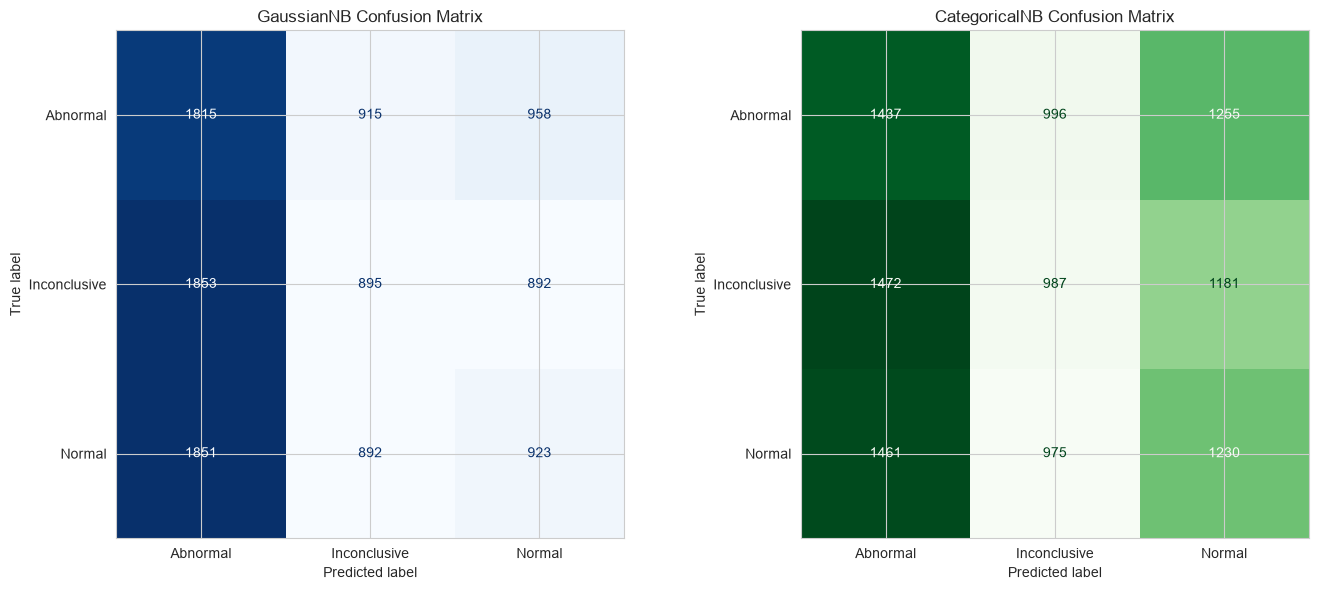

In [ ]:
# Side-by-side confusion matrices show which classes each model actually predicts
# (e.g. whether it collapses toward always predicting one class, as the baseline does by design)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
disp_gnb = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=target_encoder.classes_)
disp_gnb.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("GaussianNB Confusion Matrix")

cm_cnb = confusion_matrix(y_test, y_pred_cnb)
disp_cnb = ConfusionMatrixDisplay(confusion_matrix=cm_cnb, display_labels=target_encoder.classes_)
disp_cnb.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("CategoricalNB Confusion Matrix")

plt.tight_layout()
plt.show()

### 7.3 Model Comparison

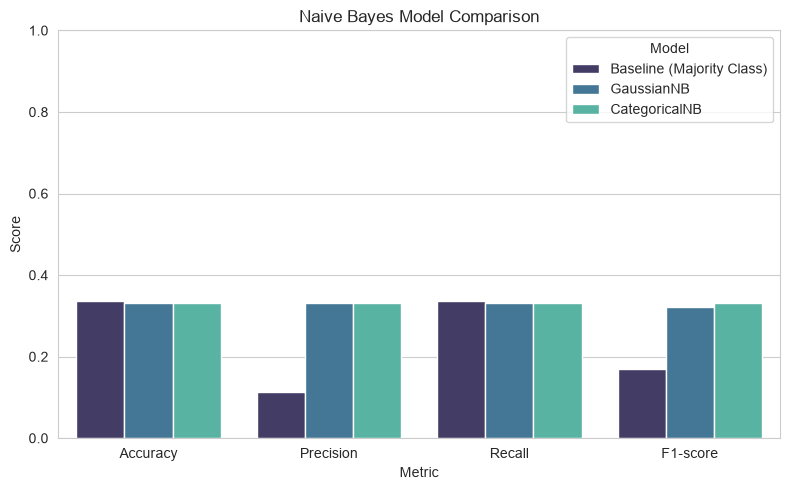

In [ ]:
# Melt to long format so seaborn can group bars by Model within each Metric on one shared axis
plt.figure(figsize=(8,5))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model", palette="mako")
plt.title("Naive Bayes Model Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Evaluation Summary:**
With actual figures from the results table and ROC-AUC cell above: the majority-class baseline
scores 33.5% accuracy, tuned GaussianNB scores 33.0%, and tuned CategoricalNB scores 33.2% - all
within a percentage point of each other and of the ~33.3% level expected by chance on this balanced
3-class problem. The multi-class ROC-AUC scores (Section 7.1) are 0.500 for GaussianNB and 0.497 for
CategoricalNB - both statistically indistinguishable from 0.5, confirming numerically (not just by
comparison to the baseline) that neither model's predicted class probabilities carry real ranking
information. Hyperparameter tuning found a best `var_smoothing` of ~0.113 for GaussianNB and a best
`alpha` of 0.5 for CategoricalNB (Section 6) - neither materially changed the outcome, which rules
out "bad defaults" as the explanation. Given `Test Results` shows almost no association with any
available feature in the EDA (Sections 4.5-4.7), this is the expected outcome for this dataset, not
evidence of a modelling error: performance here is bounded by the information content of the
available features, not by the algorithm or its configuration.

## 8. Discussion: Ethical, Social and Future Implications

**Ethical implications:**
- Healthcare data is highly sensitive; even in this de-identified/synthetic dataset, real-world deployment would require strict compliance with data protection regulations (e.g., HIPAA, PDPA) and informed patient consent.
- A model with accuracy at the majority-class baseline and ROC-AUC near 0.5 (Section 7.1) provides no real discriminative signal and should **not** be used to inform real clinical decisions, as incorrect predictions of "Abnormal" or "Normal" test outcomes could lead to misdiagnosis, delayed treatment, or unnecessary interventions.
- Bias could be introduced if certain demographic groups (e.g., by insurance provider, a proxy for socioeconomic status) are systematically mis-predicted, potentially widening healthcare inequities.

**Social implications:**
- Reliable predictive tools could reduce clinician workload and speed up triage, but overreliance on an inaccurate model could erode patient trust in AI-assisted healthcare systems.
- Transparency about model limitations (e.g., publishing accuracy/precision/recall/ROC-AUC, and comparing against a simple baseline as done here) is essential so clinicians treat predictions as a decision-support signal rather than ground truth.

**Future implications:**
- Performance could likely be improved with richer features - actual lab values, vital signs, prior medical history, or longitudinal records - rather than administrative fields like insurance provider or room number.
- Future work could explore ensemble methods (Random Forest, Gradient Boosting) or deep learning on time-series clinical data, alongside explainability techniques (e.g., SHAP) to build clinician trust.
- Regular model monitoring and retraining would be required to prevent performance drift as hospital processes and patient populations change over time.

## 9. Conclusion

This notebook loaded the Kaggle Healthcare Dataset (55,500 raw observations, 15 features; 54,966 after removing 534 exact duplicates), cleaned and
type-converted it, explored it visually (including explicit outlier screening via boxplots and the
IQR rule), engineered a `Length of Stay` feature, and trained two Naive Bayes variants (Gaussian and
Categorical) - each with its key hyperparameter tuned via cross-validation - to predict
`Test Results`. Both tuned models performed statistically indistinguishably from a majority-class
baseline and produced ROC-AUC scores near 0.5, reflecting the limited predictive signal in the
available administrative features (as already suggested by the EDA) rather than a shortcoming of
Naive Bayes or its configuration. Ethical caution, additional clinically meaningful features (lab
values, vital signs, prior history), and human oversight are recommended before any real-world
deployment.